In [4]:
from google.colab import files
uploaded = files.upload()

Saving LassoHomotopy.py to LassoHomotopy.py
Saving small_test.csv to small_test (1).csv


In [5]:
!ls

 LassoHomotopy.py   sample_data  'small_test (1).csv'   small_test.csv


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# Import the LassoHomotopyModel from the uploaded file
from LassoHomotopy import LassoHomotopyModel

# Set a random seed for reproducibility
np.random.seed(42)


In [7]:
# Load the dataset
data = pd.read_csv('small_test.csv')

# Display the first few rows
data.head()

,x_0,x_1,x_2,y
0,-2.421349,6.290215,2.516304,10.240120
1,8.134658,-6.975969,-3.281095,-6.896294
2,-0.453124,0.058895,-3.592293,14.104288
3,3.979833,-8.129002,9.202915,-43.788868
4,-4.354232,2.472475,8.459722,-12.067617


In [8]:
# Check if the 'target' column exists; otherwise assume the last column is the target
if 'target' in data.columns:
    X = data.drop(columns=['target']).values
    y = data['target'].values
else:
    X = data.iloc[:, :-1].values
    y = data.iloc[:, -1].values

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)


Shape of X: (50, 3)
Shape of y: (50,)


In [9]:
# Instantiate and fit the Lasso Homotopy Model
model = LassoHomotopyModel(n_lambdas=100, max_iter=1000, tol=1e-6)
results = model.fit(X, y)

# Extract the coefficient, intercept, and lambda paths
coef_path = results.coef_path    # shape: (n_features, n_lambdas)
intercept_path = results.intercept_path  # shape: (n_lambdas,)
lambda_path = results.lambda_path        # shape: (n_lambdas,)

print("Coefficient path shape:", coef_path.shape)
print("Intercept path shape:", intercept_path.shape)
print("Lambda path shape:", lambda_path.shape)


Coefficient path shape: (3, 100)
Intercept path shape: (100,)
Lambda path shape: (100,)


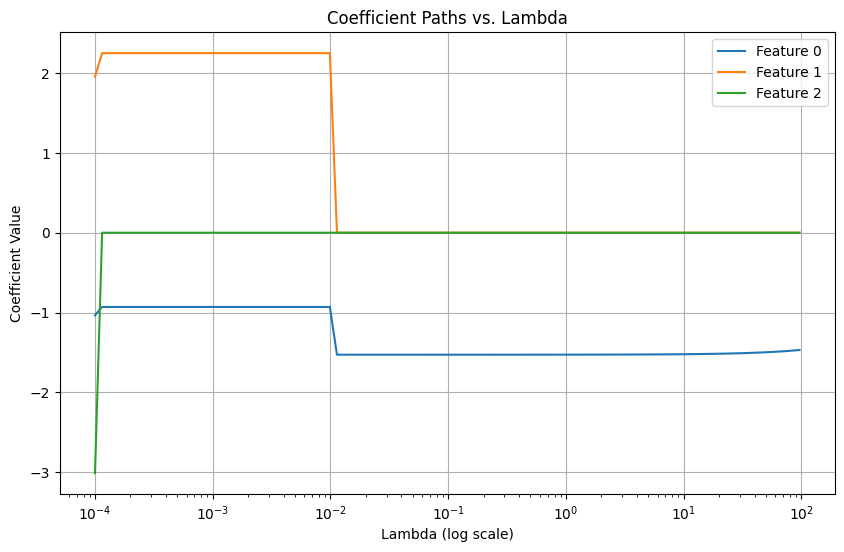

In [10]:
plt.figure(figsize=(10, 6))
for i in range(coef_path.shape[0]):
    plt.plot(lambda_path, coef_path[i, :], label=f'Feature {i}')
plt.xscale('log')
plt.xlabel('Lambda (log scale)')
plt.ylabel('Coefficient Value')
plt.title('Coefficient Paths vs. Lambda')
plt.legend()
plt.grid(True)
plt.show()


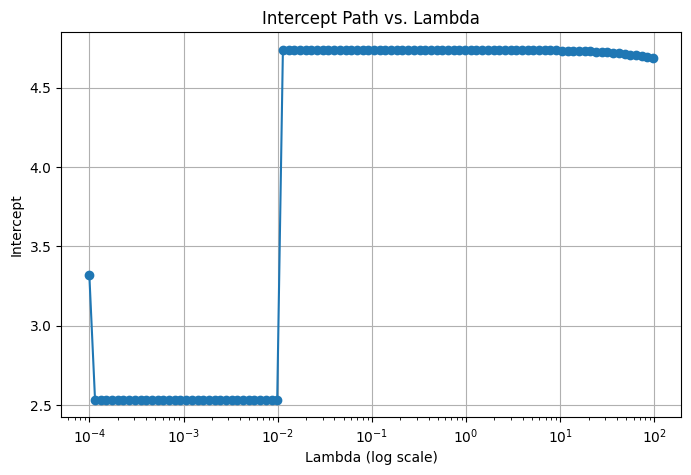

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(lambda_path, intercept_path, marker='o')
plt.xscale('log')
plt.xlabel('Lambda (log scale)')
plt.ylabel('Intercept')
plt.title('Intercept Path vs. Lambda')
plt.grid(True)
plt.show()

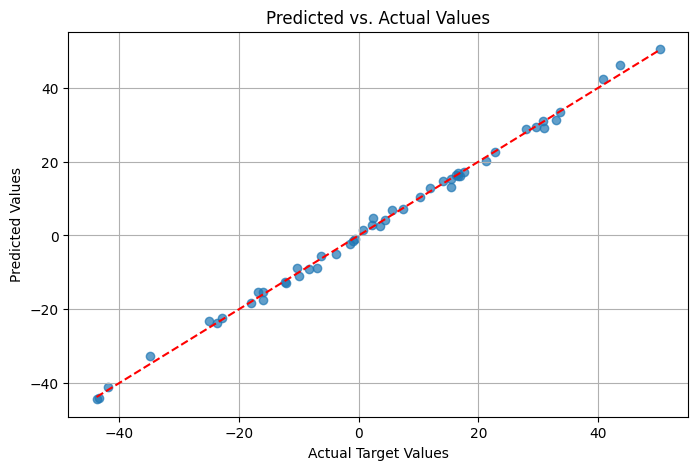

In [12]:
# Select the lambda index for prediction (using the last lambda value to approximate OLS)
best_lambda_idx = -1
results.set_best_lambda(best_lambda_idx)
y_pred = results.predict(X)

plt.figure(figsize=(8, 5))
plt.scatter(y, y_pred, alpha=0.7)
plt.xlabel('Actual Target Values')
plt.ylabel('Predicted Values')
plt.title('Predicted vs. Actual Values')
plt.plot([min(y), max(y)], [min(y), max(y)], 'r--')  # Reference line (y=x)
plt.grid(True)
plt.show()
